<a href="https://colab.research.google.com/github/adaryass/Financial-applications-with-Python/blob/main/VaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **VaR**

#### Définition du VaR (Value at Risk)

Le VaR (Value at Risk) est une mesure statistique clé pour évaluer les pertes financières potentielles d'un investissement ou d'un portefeuille. Il répond à la question : "Quelle est la perte maximale que je peux subir avec une probabilité donnée sur une période spécifiée ?"

*   **Exemple**: Un VaR de 1 million d'euros à 99% sur 1 jour signifie 1% de chances de perdre plus de 1 million d'euros sur une journée.

#### Les Différentes Méthodes de Calcul du VaR

Il existe trois méthodes principales, chacune avec ses propres caractéristiques et applications :

##### 1. VaR Historique (Non-Paramétrique)

*   **Concept**: Utilise les données historiques réelles des rendements du portefeuille. Aucune hypothèse sur la distribution.
*   **Fonctionnement**: Triage des rendements passés pour trouver le percentile correspondant au niveau de confiance.
*   **Avantages**: Simple, facile à implémenter, ne nécessite pas d'hypothèses de distribution.
*   **Inconvénients**: S'appuie fortement sur le passé, ne capture pas les événements inédits.

##### 2. VaR Analytique (ou Paramétrique)

*   **Concept**: Suppose que les rendements suivent une distribution statistique spécifique (souvent normale). Utilise des formules mathématiques.
*   **Fonctionnement**: Calcul basé sur la moyenne (μ) et l'écart-type (σ) des rendements: `VaR = μ - Z * σ`.
*   **Avantages**: Rapide à calculer, ne nécessite pas de simulations.
*   **Inconvénients**: Les rendements réels ne sont pas toujours normaux (queues épaisses), les résultats peuvent être imprécis si l'hypothèse de normalité est violée.

##### 3. VaR Monte Carlo (Simulations)

*   **Concept**: Génère un grand nombre de scénarios futurs de rendements basés sur des hypothèses de distribution (normale, Student-t, etc.).
*   **Fonctionnement**:
    1.  Modélisation des distributions d'actifs et de leurs corrélations.
    2.  Simulation de multiples parcours futurs.
    3.  Calcul des rendements du portefeuille pour chaque scénario.
    4.  Détermination du VaR à partir des rendements simulés triés.
*   **Avantages**: Très flexible, gère des distributions complexes et relations non linéaires, peut intégrer des hypothèses plus réalistes.
*   **Inconvénients**: Intensif en calcul, peut être lent, les résultats dépendent de la justesse des hypothèses de distribution.

---

Le choix de la méthode dépend de la complexité du portefeuille, de la nature des actifs et des ressources de calcul disponibles.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

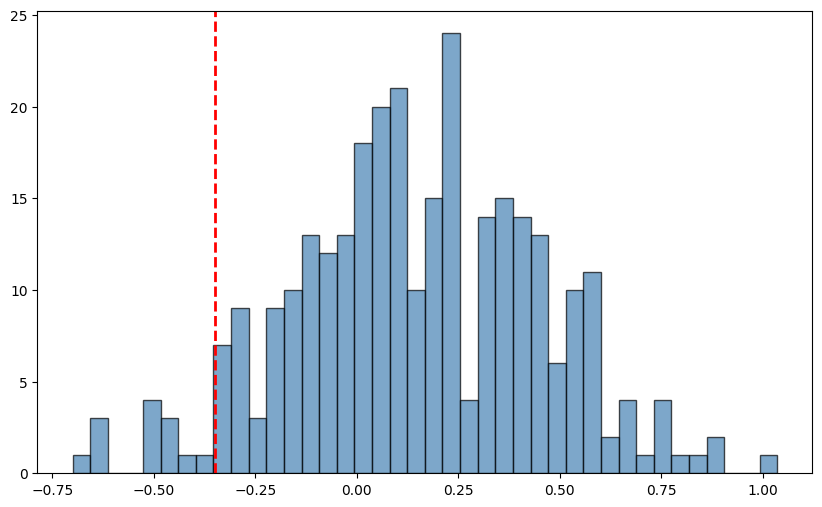

In [ ]:
from matplotlib.lines import lineStyles
mu = 0.15
sigma =0.30

random = np.random.normal(mu, sigma, size =300)
var = np.percentile(random, 100*0.05)
plt.figure(figsize = (10,6))
plt.hist(random, bins = 40, alpha = 0.7, color = 'steelblue', edgecolor = 'black')
plt.axvline(var, color = 'red',linestyle = '--', linewidth = 2)

#### Exercice VaR

/tmp/ipykernel_578/1653200804.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_578/1653200804.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_578/1653200804.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_578/1653200804.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True


<function matplotlib.pyplot.show(close=None, block=None)>

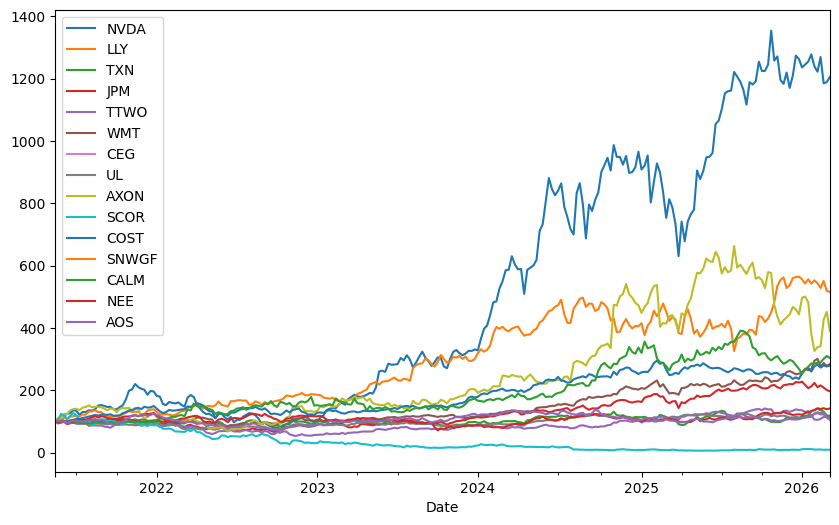

In [7]:
#choosing stock list
list_tickers = ['NVDA', 'LLY', 'TXN', 'JPM', 'TTWO', 'WMT', 'CEG', 'UL', 'AXON', 'SCOR', 'COST', 'SNWGF', 'CALM', 'NEE','AOS']
ptf_assets = pd.DataFrame()
today_date = datetime.today()
year_prior = today_date - timedelta(weeks = 252)
str_today = today_date.strftime("%Y-%m-%d")
str_year_prior = year_prior.strftime("%Y-%m-%d")

#download prices
for ticker in list_tickers:
       ptf_assets[ticker] = yf.download(ticker, start = str_year_prior, end = str_today, interval = '1wk')['Close']
(ptf_assets/ptf_assets.iloc[0] * 100).plot(figsize = (10,6))
plt.show

In [5]:
#log returns
asset_returns = np.log(ptf_assets/ptf_assets.shift(1))
#annualizing returns
retuns_annual = asset_returns.mean() * 52
#standard deviation of returns
asset_risks = asset_returns.std() * np.sqrt(52)
#covariance matrix
ptf_covariance = asset_returns.cov()
#correlation matrix
ptf_correlation = asset_returns.corr()

In [8]:
#set empty series to store the monte carlo iteration data
portfolio_returns = []
portfolio_volatility = []
portfolio_weights = []

for x in range(1000000):
    #assing random weights
    weights = np.random.uniform(0, 1, ptf_assets.shape[1])
    #weights as a condition that their sum should be equal to 1
    weights /= np.sum(weights)
    #calculate portfolio returns
    portfolio_returns.append(np.dot(weights,retuns_annual))
    #calculate portfolio volatility
    portfolio_volatility.append(np.sqrt(np.dot(weights.T,np.dot(ptf_covariance * 52 ,weights))))
    #append the weights
    portfolio_weights.append(weights)
portfolio_returns = np.array(portfolio_returns)
portfolio_volatility = np.array(portfolio_volatility)
porftolio_weights = np.array(portfolio_weights)

In [45]:
portfolios = pd.DataFrame({ 'returns' : portfolio_returns, 'volatility' : portfolio_volatility, 'weights' : list(portfolio_weights)})


portfolio_value = 100000000
#determine the min var portfollio
optimal_portfolio_volatility = portfolios['volatility'].min()
placement = portfolios[portfolios['volatility'] == optimal_portfolio_volatility]['returns']
placement2 = portfolios[portfolios['volatility'] == optimal_portfolio_volatility]['weights']
optimal_portfolio_return = placement.values[0]
optimal_portfolio_weights = placement2.values[0]
#min var portfolio weights
optimal_assets_weights = pd.DataFrame(optimal_portfolio_weights, index = list_tickers, columns = ["Optimal Weights"])
print(optimal_assets_weights)

       Optimal Weights
NVDA          0.012903
LLY           0.099281
TXN           0.031746
JPM           0.090798
TTWO          0.123169
WMT           0.156434
CEG           0.006906
UL            0.181973
AXON          0.008170
SCOR          0.023653
COST          0.041766
SNWGF         0.015672
CALM          0.063369
NEE           0.020690
AOS           0.123470


##### 1) VaR Historique

In [48]:
import numpy as np
import matplotlib.pyplot as plt

def historical_var(weights, returns, confidence_level):
    ptf_returns = []
    weights_array = np.array(weights)

    for t in returns.index:
        tstamp_returns = np.array(returns.loc[t])
        ptf_returns.append(np.dot(weights_array, tstamp_returns))

    # Filtrer les rendements (optionnel)
    threshold = 0.11
    filtered_returns = [_ for _ in ptf_returns if abs(_) <= threshold]

    alpha = 1 - confidence_level
    var_return = np.percentile(filtered_returns, 100 * alpha)
    var_money = abs(var_return) * portfolio_value

    # Plot distribution
    plt.figure(figsize=(7, 5))
    plt.hist(filtered_returns, bins=40, alpha=0.7,
             color='steelblue', edgecolor='black')
    plt.axvline(var_return, color='red', linestyle='--', linewidth=2)
    plt.text(
        var_return,
        plt.ylim()[1] * 0.9,
        f"VaR = {var_return:.4f}",
        color='red'
    )

    plt.title(f"Portfolio Return Distribution with {int(confidence_level * 100)}% Historical VaR")
    plt.xlabel("Portfolio Returns")
    plt.ylabel("Frequency")
    plt.show()

    return var_return, var_money, #filtered_returns,

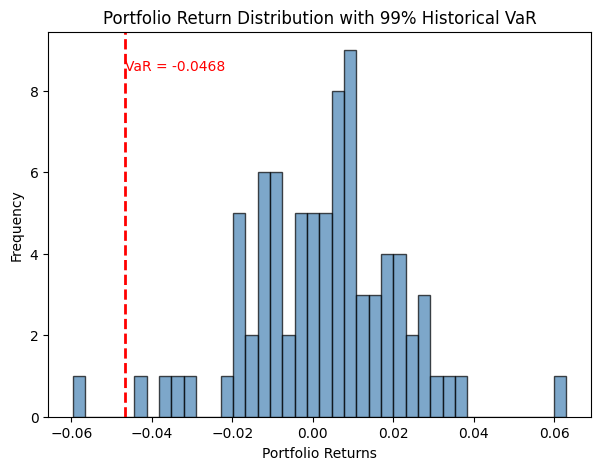

(np.float64(-0.046760665753837694), np.float64(4676066.575383769))

In [49]:
historical_var(optimal_portfolio_weights, asset_returns, 0.99)

#### 2) VaR Analystique

##### a) Loi Normale

In [52]:
from scipy.stats import norm

def analytical_var(T, mu, sigma):
  mu_d = optimal_portfolio_return*T
  sigma_d = optimal_portfolio_volatility*np.sqrt(T)

  var_d = mu_d + norm.ppf(0.01)*sigma_d
  var_money = abs(var_d) * portfolio_value
  return var_d, var_money

In [53]:
analytical_var(10/252, optimal_portfolio_return, optimal_portfolio_volatility)

(np.float64(-0.06130221886573199), np.float64(6130221.886573199))

In [54]:
#retrieving the risk free rate
risk_free = yf.download("^TNX", start = str_year_prior, end = str_today, interval = "1wk")['Close']
rf = (risk_free/100).mean()

/tmp/ipykernel_578/630092469.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  risk_free = yf.download("^TNX", start = str_year_prior, end = str_today, interval = "1wk")['Close']
[*********************100%***********************]  1 of 1 completed


In [55]:
#calculating the sharp ratio
portfolios['Sharpe ratio'] = (portfolios['returns'] - rf.values) / portfolios['volatility']
#max sharp porftolio
max_sharp = portfolios[portfolios['Sharpe ratio'] == portfolios['Sharpe ratio'].max()]
max_sharp_weights = pd.DataFrame(max_sharp['weights'].values[0], index = list_tickers, columns=['Max Sharp Weights'])
max_sharpe_returns =max_sharp['returns'].values[0]
max_sharpe_volatility = max_sharp['volatility'].values[0]

In [56]:
max_sharp

,returns,volatility,weights,Sharpe ratio
166385,0.336729,0.18907,"[0.11130897745184576, 0.0980890886056763, 0.02...",1.593056


In [57]:
analytical_var(10/252, max_sharpe_returns, max_sharpe_volatility)

(np.float64(-0.06130221886573199), np.float64(6130221.886573199))

#### 3) VaR Monte Carlo

###### a) Distribution Normale

In [58]:
def VaR_MonteCarlo(T, mu, sigma, size, confidence_level):

  mu_d = mu*T
  sigma_d = sigma*np.sqrt(T)
  # Generating returns under normal distribution
  simulated_returns = np.random.normal(mu_d, sigma_d, size)
  # Calculating the VaR
  alpha = 1 - confidence_level
  var = np.percentile(simulated_returns, 100 * alpha)
  var_money = abs(var) * portfolio_value
  # plot to show
  plt.figure(figsize=(10, 5))
  plt.hist(simulated_returns, bins =50, color = '#2E86C1', alpha = 0.75)
  plt.axvline(var, color = 'red', linestyle = '--', linewidth = 2)
  plt.text(var, plt.ylim()[1] * 0.9, f"VaR = {var:.4f}", color = 'red')
  plt.title(f"Portfolio Return Distribution with {int(confidence_level * 100)}% Monte Carlo VaR")
  plt.xlabel("Portfolio Returns")
  plt.ylabel("Frequency")
  plt.show()

  return var, var_money

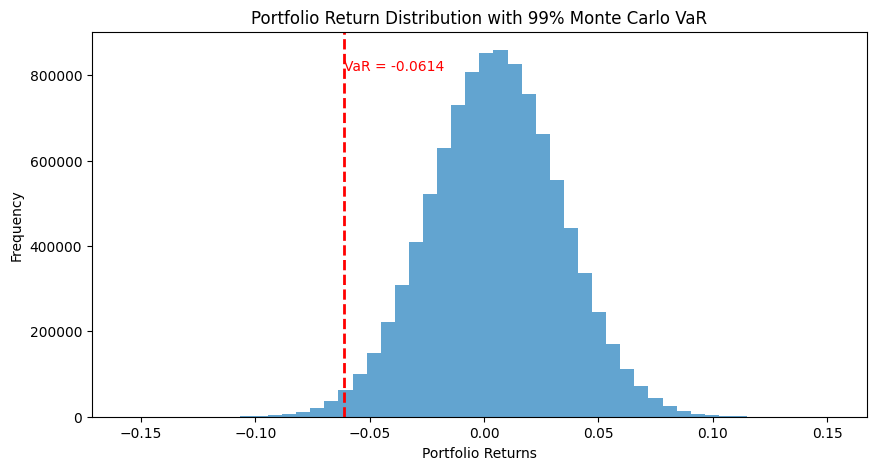

(np.float64(-0.06135208310954756), np.float64(6135208.310954756))

In [59]:
VaR_MonteCarlo(10/252, optimal_portfolio_return, optimal_portfolio_volatility, 10000000, 0.99)

###### b) Loi de Student

Distribution t de Student sous hypothèses normales :

*   Utilisée pour les échantillons de petite taille ($n < 30$).
*   Définie par un seul paramètre noté $\nu$ (degrés de liberté).
*   Notation $t_{\nu}$ :

    *   Moyenne $= 0$ pour $\nu > 1$
    *   Variance $= \frac{\nu}{\nu - 2}$ pour $\nu > 2$
    *   Symétrique et capture les queues lourdes (heavy tails).

Mais dans les rendements réels des actifs : Moyenne $> 0$
Nous introduisons donc 2 paramètres : $\mu$ et $\Sigma$

Notation $X \sim t(\mu, \Sigma)$
La variable $X$ prend donc la valeur : $X = \mu + \sigma \cdot T$ (nous supposons : $\nu = 5$)

$\nu = 5$ (Standard)

In [60]:
from scipy.stats import t

def t_student_var(T, mu, sigma, size, confidence_level, df):

    # initiating parameters for the time horizon
    mu_d = mu * T
    sigma_d = sigma * np.sqrt(T)

    # simulate returns from Student-t distribution
    simulated_returns = mu_d + sigma_d * t.rvs(df, size=size)

    # calculating VaR
    alpha = 1 - confidence_level
    var = np.percentile(simulated_returns, 100 * alpha)
    var_money = abs(var) * portfolio_value

    # plot distribution
    plt.figure(figsize=(10,5))
    plt.hist(simulated_returns, bins=50, alpha=0.75,
             color='steelblue', edgecolor='black')

    plt.axvline(var, color='red', linestyle='--', linewidth=2)
    plt.text(var, plt.ylim()[1]*0.9, f"VaR = {var:.4f}", color='red')

    plt.title(f"Portfolio Return Distribution with {int(confidence_level*100)}% Student-t VaR")
    plt.xlabel("Portfolio Returns")
    plt.ylabel("Frequency")
    plt.show()

    return var, var_money

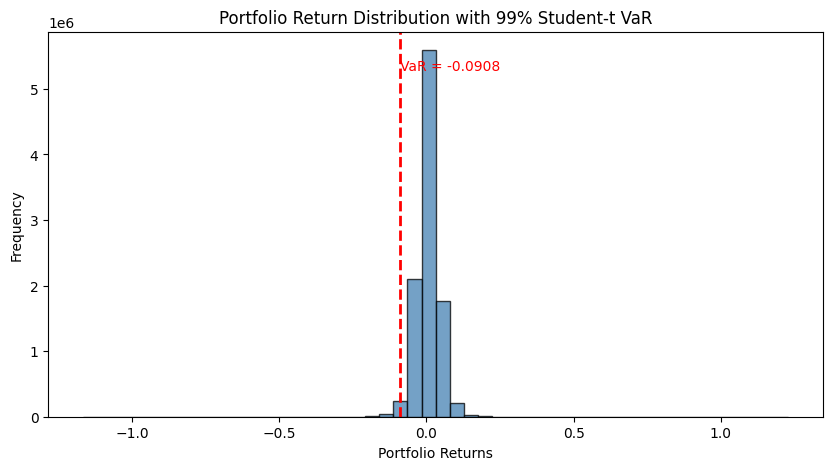

(np.float64(-0.09080236362974697), np.float64(9080236.362974698))

In [61]:
t_student_var(10/252, optimal_portfolio_return, optimal_portfolio_volatility, 10000000, 0.99, 5)